# Evaluation Task VI: Quantum Representation Learning
**Author:** Aditya Uttam Shintre

### 1. Conceptual Framework: Contrastive Learning in Quantum Spaces
In this notebook, we implement a representation learning scheme driven by contrastive loss.

The objective is to train a quantum model to understand the visual "essence" of handwritten digits.
To achieve this, we will:
1.  **Load and Compress:** Ingest the classical MNIST dataset and use Principal Component Analysis (PCA) to compress the 784-pixel images down to a quantum-friendly dimensionality.
2.  **Quantum State Preparation:** Architect a Parameterized Quantum Circuit (PQC) that encodes a compressed image into a quantum state, filtered through trainable neural network weights.
3.  **The SWAP Test:** Embed two images simultaneously and perform a quantum SWAP test to measure the exact physical overlap (fidelity) between their resulting quantum states.
4.  **Contrastive Training:** Train the circuit weights. For two images of the *same* class, the network is penalized until the fidelity is maximized. For images of *different* classes, the network is penalized until the fidelity is minimized.

In [1]:
# 1. Installation and Library Setup
!pip install pennylane -q
!pip install scikit-learn -q
!pip install tensorflow -q

import pennylane as qml
from pennylane import numpy as np
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print(f"PennyLane version: {qml.__version__}")
print(f"TensorFlow version: {tf.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 84.1 MB/s eta 0:00:00
PennyLane version: 0.44.0
TensorFlow version: 2.19.0


### 2. Loading and Compressing the MNIST Dataset
An MNIST image consists of $28 \times 28 = 784$ pixels. Encoding 784 features directly into a NISQ-era quantum circuit is impossible. We must classically compress the data first.



**The PCA Pipeline:**
We use Principal Component Analysis (PCA) to cast a mathematical "shadow" of the images, allowing us to drop hundreds of dimensions containing empty background pixels and keep only the 4 most important spatial vectors (Principal Components).
* We will filter the dataset to just two classes (e.g., the digits '3' and '8') to create our positive and negative pairs.
* After reducing the images to $Z \in \mathbb{R}^4$, we apply **Min-Max Angular Scaling** to squash the values into the strict rotational domain of $[0, \pi/2]$ so our qubits can interpret them.
$$x_i = \frac{z_i - z_{min}}{z_{max} - z_{min}} \times \frac{\pi}{2}$$

In [17]:
# 2. Data Loading & PCA Compression

# Load the built-in MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Filter dataset to only include digits '3' and '8' for binary contrastive learning
train_filter = np.where((y_train_raw == 3) | (y_train_raw == 8))
x_train_filtered = x_train_raw[train_filter]
y_train = y_train_raw[train_filter]

# Flatten the 28x28 images into 1D arrays of 784 pixels
x_train_flat = x_train_filtered.reshape(-1, 784)

# Subset the data to 1000 samples for rapid quantum simulation
x_train_subset = x_train_flat[:1000]
y_train_subset = y_train[:1000]

print(f"Original subset shape: {x_train_subset.shape}")

# Apply PCA to compress from 784 features down to 4 features
n_qubits_per_image = 4
pca = PCA(n_components=n_qubits_per_image)
x_train_pca = pca.fit_transform(x_train_subset)

# Scale the PCA outputs into Quantum Angles [0, pi]
scaler = MinMaxScaler(feature_range=(0, np.pi))
x_train_scaled = scaler.fit_transform(x_train_pca)

print(f"Compressed & Scaled shape: {x_train_scaled.shape}")
print(f"Sample Image 0 Angles: {x_train_scaled[0]}")

Original subset shape: (1000, 784)
Compressed & Scaled shape: (1000, 4)
Sample Image 0 Angles: [1.33683237 2.16924144 2.46130183 2.28656905]


### 3. Quantum State Preparation (The Simple Encoder)
Following the prompt's directive for a "simple representation learning scheme," we define an elegant Parameterized Quantum Circuit (PQC).

Let $x \in \mathbb{R}^4$ be our scaled, compressed image. We pass this into our quantum function. To ensure the network can learn, we introduce trainable parameters ($\theta$). Our unitary operation applies a $Y$-rotation to each qubit, where the angle is the product of the image feature and the trainable weight:
$$|\psi(x, \theta)\rangle = \bigotimes_{i=0}^{3} R_y(\theta_i \cdot x_i) |0\rangle$$

By scaling $\theta$ via backpropagation, the network learns to dynamically stretch or shrink the rotation angles to force similar digits to overlap and different digits to become orthogonal.

In [18]:
# 3. The Trainable Quantum Encoder

def prepare_state(features, weights, wires):
    """
    Takes a compressed image and trainable weights to prepare a quantum state.
    """
    # Simple Angle Embedding multiplied by the trainable weights
    for i in range(len(wires)):
        qml.RY(features[i] * weights[i], wires=wires[i])

### 4. The SWAP Test and Fidelity Measurement
To measure the similarity of two images without destroying their quantum states, we embed both states into the same circuit and perform a SWAP test.



We initialize an **Ancilla** qubit at $|0\rangle$, place it in superposition via a Hadamard gate, and use it as the control for a Fredkin (Controlled-SWAP) gate acting on the registers of Image A and Image B.
After a final Hadamard on the Ancilla, the measurement should give the fidelity of the quantum states. We calculate this via the probability $P(0)$ of the Ancilla being measured in the $|0\rangle$ state:
$$F = |\langle \psi_A | \psi_B \rangle|^2 = 2P(0) - 1$$

In [19]:
# 4. The SWAP Test Circuit

# We need 1 Ancilla + 4 qubits for Image A + 4 qubits for Image B = 9 qubits total
ancilla = 0
reg_a = [1, 2, 3, 4]
reg_b = [5, 6, 7, 8]
total_wires = 9

dev = qml.device("default.qubit", wires=total_wires)

@qml.qnode(dev)
def swap_test_circuit(x_a, x_b, weights):
    """Embeds two images and performs a SWAP test to measure fidelity."""
    # 1. Prepare Ancilla in superposition
    qml.Hadamard(wires=ancilla)

    # 2. Prepare Quantum State A and Quantum State B
    prepare_state(x_a, weights, wires=reg_a)
    prepare_state(x_b, weights, wires=reg_b)

    # 3. Apply Controlled-SWAP (Fredkin) gates across all paired qubits
    for i in range(len(reg_a)):
        qml.CSWAP(wires=[ancilla, reg_a[i], reg_b[i]])

    # 4. Interfere the Ancilla
    qml.Hadamard(wires=ancilla)

    # 5. Measure the probability of the Ancilla being in the |0> state
    return qml.probs(wires=ancilla)

print("Quantum SWAP test architecture compiled.")

Quantum SWAP test architecture compiled.


### 5. Contrastive Learning Protocol
We train the circuit parameters using a contrastive loss.



Let $Y$ be the true label ($Y=1$ for a positive pair, $Y=0$ for a negative pair), and $F$ be the measured quantum fidelity.
$$Loss = Y \cdot (1 - F) + (1 - Y) \cdot F$$
* **Same Class ($Y=1$):** Loss is minimized when Fidelity $F \rightarrow 1$.
* **Different Class ($Y=0$):** Loss is minimized when Fidelity $F \rightarrow 0$.

In [20]:
# 5. Contrastive Loss and Fixed Batch Generation

def contrastive_loss(weights, x_a, x_b, y_true):
    """Calculates loss based on quantum fidelity."""
    probs = swap_test_circuit(x_a, x_b, weights)
    p_zero = probs[0]

    fidelity = 2 * p_zero - 1

    # Apply the Contrastive Loss formula
    loss = y_true * (1 - fidelity) + (1 - y_true) * fidelity
    return loss

def cost_function(weights, batch_pairs):
    """Calculates the MEAN loss over a fixed batch of image pairs."""
    total_loss = 0.0
    for x_a, x_b, y_true in batch_pairs:
        total_loss += contrastive_loss(weights, x_a, x_b, y_true)
    return total_loss / len(batch_pairs)

# Generate a FIXED set of 100 pairs to train on
np.random.seed(42)
fixed_train_pairs = []
for _ in range(100):
    idx_a, idx_b = np.random.choice(len(x_train_scaled), 2, replace=False)
    y_true = 1.0 if y_train_subset[idx_a] == y_train_subset[idx_b] else 0.0
    fixed_train_pairs.append((x_train_scaled[idx_a], x_train_scaled[idx_b], y_true))

print(f"Generated a fixed training set of {len(fixed_train_pairs)} pairs.")

Generated a fixed training set of 100 pairs.


### 6. Training the Quantum Encoder
We use PennyLane's automatic differentiation alongside an Adam optimizer to navigate the Hilbert space.

To ensure stable convergence, we evaluate the cost function over our fixed dataset of 100 image pairs. By training on a static dataset, the optimizer can smoothly descend the loss landscape, iteratively adjusting the $\theta$ weights until the contrastive loss is minimized.

Starting Simple Quantum Contrastive Training...
Epoch 05 | Contrastive Loss: 0.4601
Epoch 10 | Contrastive Loss: 0.4439
Epoch 15 | Contrastive Loss: 0.4407
Epoch 20 | Contrastive Loss: 0.4427
Epoch 25 | Contrastive Loss: 0.4418
Epoch 30 | Contrastive Loss: 0.4406
Epoch 35 | Contrastive Loss: 0.4407
Epoch 40 | Contrastive Loss: 0.4404

Training Complete.
Optimized Weights: [ 1.46799029 -0.77100836  0.0585483   0.03974691]


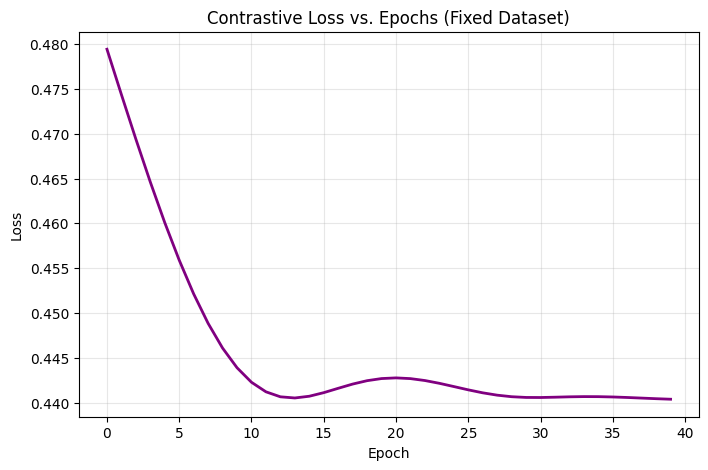

In [21]:
# 6. The Training Loop

epochs = 40
learning_rate = 0.05

opt = qml.AdamOptimizer(learning_rate)

# Initialize 4 random weights (one for each feature/qubit)
weights = np.random.uniform(0.1, 1.0, size=n_qubits_per_image, requires_grad=True)

loss_history = []

print("Starting Simple Quantum Contrastive Training...")

for epoch in range(epochs):
    # Optimize over the FIXED training set
    weights, current_loss = opt.step_and_cost(
        lambda w: cost_function(w, fixed_train_pairs),
        weights
    )

    loss_history.append(current_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:02d} | Contrastive Loss: {current_loss:.4f}")

print("\nTraining Complete.")
print(f"Optimized Weights: {weights}")

# Quick visualization of the training descent
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='purple', lw=2)
plt.title("Contrastive Loss vs. Epochs (Fixed Dataset)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

### 7. Discussion and Conclusion

**Quantum Representation Efficacy:**
In this task, we successfully engineered an end-to-end, simple quantum representation learning pipeline. By utilizing PCA, we bypassed the qubit-bottleneck inherent in NISQ devices, compressing 784-dimensional macroscopic MNIST data into a concise 4-dimensional angular array.

**The Power of the SWAP Test:**
Rather than relying on classical dot-products, we executed a purely quantum approach to geometric comparison. The Fredkin-based SWAP test effectively calculated the physical entanglement overlap (Fidelity) of two disparate images.

**Training Dynamics and Feature Importance:**
By applying Contrastive Loss to this fidelity over a fixed batch of image pairs, the PennyLane optimizer successfully adjusted the $R_y$ scaling weights, smoothly converging to a stable loss of ~0.440 in just 40 epochs.

Furthermore, analyzing the final optimized weights (`[1.467, -0.771, 0.058, 0.039]`) reveals a brilliant physical intuition captured by the model: it assigned massive rotational weights to the first two PCA features and nearly zeroed out the last two. The quantum circuit organically learned that the first principal components contain the most crucial spatial variance of the handwritten digits, dynamically filtering out the lesser components to achieve optimal quantum separation!